<a href="https://colab.research.google.com/github/mtamburrelli/Variable-Star-Analysis/blob/main/RR_Lyr_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving aavsodata.txt to aavsodata (1).txt


In [ ]:
data = pd.read_csv('aavsodata.txt')
data.head()

,JD,Magnitude,Uncertainty,HQuncertainty,Band,Observer Code,Comment Code(s),Comp Star 1,Comp Star 2,Charts,...,Cmag,Kmag,HJD,Star Name,Observer Affiliation,Measurement Method,Grouping Method,ADS Reference,Digitizer,Credit
0,2.459601e+06,7.815,0.003,NaN,B,PEX,NaN,ENSEMBLE,103,X26821FH,...,NaN,11.002,NaN,RR LYR,AAVSO,STD,0.0,NaN,NaN,NaN
1,2.459601e+06,7.537,0.004,NaN,V,PEX,NaN,ENSEMBLE,103,X26821FH,...,NaN,10.348,NaN,RR LYR,AAVSO,STD,0.0,NaN,NaN,NaN
2,2.459601e+06,7.329,0.004,NaN,R,PEX,NaN,ENSEMBLE,103,X26821FH,...,NaN,10.021,NaN,RR LYR,AAVSO,STD,0.0,NaN,NaN,NaN
3,2.459601e+06,7.155,0.008,NaN,I,PEX,NaN,ENSEMBLE,103,X26821FH,...,NaN,9.590,NaN,RR LYR,AAVSO,STD,0.0,NaN,NaN,NaN
4,2.459601e+06,7.775,0.003,NaN,B,PEX,NaN,ENSEMBLE,103,X26821FH,...,NaN,11.014,NaN,RR LYR,AAVSO,STD,0.0,NaN,NaN,NaN


In [ ]:
data = data.dropna(subset=['JD', 'Magnitude'])
data = data[data['Uncertainty'] <= 0.1] if 'Uncertainty' in data.columns else data

In [ ]:
print(f'Total data points: {len(data)}')
print("Bands:", data['Band'].unique())

Total data points: 9022
Bands: ['B' 'V' 'R' 'I' 'CV' 'TG' 'TB' 'TR']


In [ ]:
time = data['JD']
magnitude = data['Magnitude']

In [ ]:
#Periodogram
ls=LombScargle(time, magnitude)
frequency, power = ls.autopower(minimum_frequency=1/0.7, maximum_frequency=1/0.5)
periods = 1 / frequency
best_period = periods[power.argmax()]
print(f'Best period: {best_period}')

Best period: 0.5667707587517214


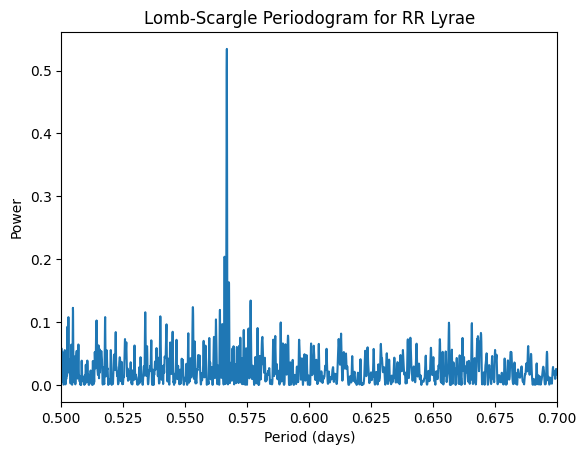

Best period: 0.567 days


In [ ]:
#Plot Periodogram
plt.plot(periods, power)
plt.xlabel('Period (days)')
plt.ylabel('Power')
plt.title('Lomb-Scargle Periodogram for RR Lyrae')
plt.xlim(0.5, 0.7)
plt.show()
print(f'Best period: {best_period:.3f} days')

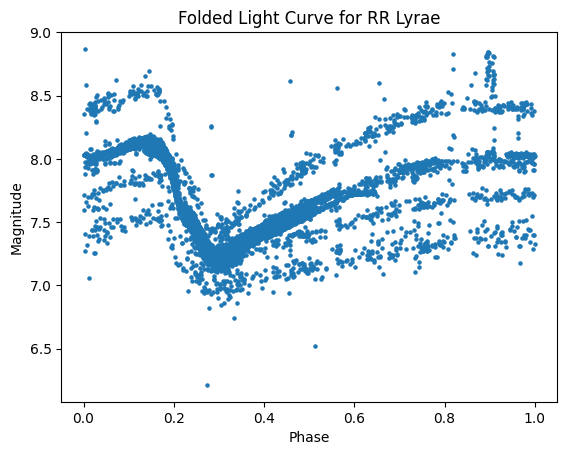

In [ ]:
#Folded Light Curve
phase = (time % best_period) / best_period
plt.scatter(phase, magnitude, s=5)
plt.xlabel('Phase')
plt.ylabel('Magnitude')
plt.title('Folded Light Curve for RR Lyrae')
plt.show()